In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

from rasterio.features import rasterize
from rasterio.transform import from_bounds

from config import *

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
USSF_filepath = geospat_data_filepath+"US_shapefiles/cb_2017_us_state_5m.shp"

In [3]:
# Reading and filtering 
basinatlas = pd.read_csv(basin_atlas_filepath+"static_basinatlas_catchment_characteristics.csv")
basinatlas = basinatlas[['STREAM_ID',
                         'clz_cl_smj', # Climate Zones (spatial maj)
                         'ari_ix_sav', # Aridity Index (spatial ave)
                         'kar_pc_sse', # Karst percentage (spatial extent %)
                         'ppd_pk_sav', # Pop density (pop km2; spatial ave)
                         'rdd_mk_sav', # Road Density (spatial ave)
                         'hft_ix_s09', # Human footprint (2009)
                         'slp_dg_sav', # Terrain slope
                         'lit_cl_smj', # Lith classes (spatial maj)
                         'ele_mt_sav'  # Average elevation
                        ]]

param_dict = {'clz_cl_smj_remap':'Climate Zones',
              'ari_ix_sav':'Aridity Index',
              'kar_pc_sse':'% Karst', 
              'ppd_pk_sav':'Pop. Density',
              'rdd_mk_sav':'Road Density',
              'hft_ix_s09':'Human footprint',
              'slp_dg_sav':'Terrain slope',
              'lit_cl_smj_remap':'Lithology classes',
              'ele_mt_sav':'Average elevation'}

# Converting to true values
basinatlas['ari_ix_sav'] = basinatlas['ari_ix_sav']/100
basinatlas['slp_dg_sav'] = basinatlas['slp_dg_sav']/10
basinatlas.head(2)

,STREAM_ID,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav
0,STREAM-gauge-1723,7.0,1.101513,0.0,12.129693,207.375630,77.930846,9.251775,3.0,633.409154
1,STREAM-gauge-2691,7.0,1.140810,0.0,23.310343,275.694486,103.656822,8.274755,3.0,591.319034


In [4]:
# Mapping cateogorical variables
clz_cl = pd.read_csv(basin_atlas_filepath+'clz_cl.csv')
clz_cl_dict = pd.Series(clz_cl.Reclassification.values, index=clz_cl.GEnZ_ID).to_dict()

lit_cl = pd.read_csv(basin_atlas_filepath+'lit_cl.csv')
lit_cl_dict = pd.Series(lit_cl.Reclassification.values, index=lit_cl.GLiM_ID).to_dict()

basinatlas['clz_cl_smj_remap'] = basinatlas['clz_cl_smj'].map(clz_cl_dict)
basinatlas['lit_cl_smj_remap'] = basinatlas['lit_cl_smj'].map(lit_cl_dict)
basinatlas.head(2)

,STREAM_ID,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav,clz_cl_smj_remap,lit_cl_smj_remap
0,STREAM-gauge-1723,7.0,1.101513,0.0,12.129693,207.375630,77.930846,9.251775,3.0,633.409154,5,Sedimentary
1,STREAM-gauge-2691,7.0,1.140810,0.0,23.310343,275.694486,103.656822,8.274755,3.0,591.319034,5,Sedimentary


In [5]:
# Processing metadata, isolating specific parameters
md_wide = pd.read_csv(metadata_filepath+"metadata.csv", dtype = {'sourceID': str})
print(f"Full dataset size: {md_wide.shape[0]}")
params = ['SpC_uScm','DO_mgL','Turb_FNU']

for param in params:
    md_wide[param] = md_wide['WQ_parameters'].str.contains(param)

# Removing the stations without data
md_wide = md_wide[(md_wide['SpC_uScm']) | (md_wide['DO_mgL']) | (md_wide['Turb_FNU'])]
print(f"Filtered dataset size: {md_wide.shape[0]}")

Full dataset size: 870
Filtered dataset size: 556


In [6]:
md = md_wide.melt(
    id_vars=['STREAM_ID', 'sourceID', 'source', 'site name', 'latitude_wgs84', 
             'longitude_wgs84', 'drainagearea_sqkm', 'state_name', 'time_zone', 'WQ_parameters'],
    value_vars=['SpC_uScm', 'DO_mgL', 'Turb_FNU'],
    var_name='parameter',
    value_name='has_data'
)
md = md[md['has_data']].drop(['WQ_parameters','has_data'],axis=1)
md.sort_values('STREAM_ID').head()

,STREAM_ID,sourceID,source,site name,latitude_wgs84,longitude_wgs84,drainagearea_sqkm,state_name,time_zone,parameter
1599,STREAM-gauge-1012,7214550,USGS,"MORA CREEK AT HOLMAN, NM",36.035217,-105.379983,NaN,New Mexico,Mountain,Turb_FNU
1043,STREAM-gauge-1012,7214550,USGS,"MORA CREEK AT HOLMAN, NM",36.035217,-105.379983,NaN,New Mexico,Mountain,DO_mgL
1600,STREAM-gauge-1013,7218525,USGS,"SAPELLO RIVER ABOVE SAPELLO, NM",35.772989,-105.304481,NaN,New Mexico,Mountain,Turb_FNU
1044,STREAM-gauge-1013,7218525,USGS,"SAPELLO RIVER ABOVE SAPELLO, NM",35.772989,-105.304481,NaN,New Mexico,Mountain,DO_mgL
1326,STREAM-gauge-1042,6418800,USGS,"RAPID CREEK ABOVE WRF NR RAPID CITY, SD",44.026806,-103.101111,1163.915606,South Dakota,Mountain,Turb_FNU


In [7]:
md_spatial_data = md.merge(basinatlas, on='STREAM_ID')
md_spatial_data.head()
#md_spatial_data.to_csv('../OUTPUT/filtered_spC_DO_turb_basinparams.csv')

,STREAM_ID,sourceID,source,site name,latitude_wgs84,longitude_wgs84,drainagearea_sqkm,state_name,time_zone,parameter,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav,clz_cl_smj_remap,lit_cl_smj_remap
0,STREAM-gauge-699,6805500,USGS,"Platte River at Louisville, Nebr",41.014978,-96.157500,221107.44630,Nebraska,Central,SpC_uScm,10.0,0.730000,0.000000,16.862000,307.000000,177.000000,1.800000,3.0,354.000000,6,Sedimentary
1,STREAM-gauge-2815,7137500,USGS,"ARKANSAS R NR COOLIDGE, KS",38.027517,-102.011577,65811.64590,Kansas,Mountain,SpC_uScm,9.0,0.344924,23.849569,9.463323,152.865259,48.414293,4.012263,3.0,1831.753307,6,Sedimentary
2,STREAM-gauge-2793,6856600,USGS,"REPUBLICAN R AT CLAY CENTER, KS",39.355552,-97.127520,63563.53458,Kansas,Central,SpC_uScm,9.0,0.434286,8.239190,2.097020,94.229848,60.629178,1.180475,3.0,957.662762,6,Sedimentary
3,STREAM-gauge-1769,3108500,USGS,"Ohio River at Montgomery Lock & Dam, Lower Pool",40.647241,-80.388666,59466.17040,Pennsylvania,Eastern,SpC_uScm,10.0,1.113137,30.842322,74.117446,797.900344,153.888438,5.843242,3.0,488.909913,6,Sedimentary
4,STREAM-gauge-3006,6174500,USGS,Milk River at Nashua MT,48.130053,-106.364314,58150.45548,Montana,Mountain,SpC_uScm,8.0,0.366990,1.075479,0.739630,54.655445,30.733556,1.922866,3.0,924.904450,5,Sedimentary


In [8]:
# Merging the temporal data derived by Sai
temporal_summary = pd.read_csv(OUTPUT_filepath+"temporal_statistics_mrb_usgs.csv")

# Identify ID/metadata columns
id_cols = ['STREAM_ID']

# Other parameters tracking
temporal_params = ['WTemp_C', 'SpC_uScm', 'DO_mgL', 'pH', 'Turb_FNU', 'Turb_NTU',
          'NO3_mgNL', 'fDOM_QSU', 'fDOM_RFU', 'DOC_mgL', 'PO4_mgL', 
          'Chla_ugL', 'Chla_RFU', 'PC_ugL', 'PC_RFU']

# Reshape
rows = []
for temp_param in temporal_params:
    temp = temporal_summary[id_cols].copy()
    temp['parameter'] = temp_param
    temp['pct_missing'] = temporal_summary[f'{temp_param}_pct_missing']
    temp['length_hr'] = temporal_summary[f'{temp_param}_length_hr']
    temp['longest_hr'] = temporal_summary[f'{temp_param}_longest_hr']
    rows.append(temp)

temporal_summary_long = (
    pd.concat(rows, ignore_index=True)
    .query('parameter in @params')
    .dropna(how='all', subset=['pct_missing', 'length_hr', 'longest_hr'])
)
temporal_summary_long.head()

,STREAM_ID,parameter,pct_missing,length_hr,longest_hr
869,STREAM-gauge-1723,SpC_uScm,4.02,129087.0,9415.0
873,STREAM-gauge-1726,SpC_uScm,11.43,15742.0,4608.0
880,STREAM-gauge-1733,SpC_uScm,50.11,156566.0,4050.0
883,STREAM-gauge-1736,SpC_uScm,5.66,128415.0,7859.0
885,STREAM-gauge-1738,SpC_uScm,5.84,147785.0,7921.0


In [11]:
md_data = md_spatial_data.merge(temporal_summary_long, on=['STREAM_ID','parameter'])
md_data.to_csv('../OUTPUT/filtered_spC_DO_turb_basinparams_tempstats.csv')
md_data.head()

,STREAM_ID,sourceID,source,site name,latitude_wgs84,longitude_wgs84,drainagearea_sqkm,state_name,time_zone,parameter,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav,clz_cl_smj_remap,lit_cl_smj_remap,pct_missing,length_hr,longest_hr
0,STREAM-gauge-699,6805500,USGS,"Platte River at Louisville, Nebr",41.014978,-96.157500,221107.44630,Nebraska,Central,SpC_uScm,10.0,0.730000,0.000000,16.862000,307.000000,177.000000,1.800000,3.0,354.000000,6,Sedimentary,47.56,156537.0,2354.0
1,STREAM-gauge-2815,7137500,USGS,"ARKANSAS R NR COOLIDGE, KS",38.027517,-102.011577,65811.64590,Kansas,Mountain,SpC_uScm,9.0,0.344924,23.849569,9.463323,152.865259,48.414293,4.012263,3.0,1831.753307,6,Sedimentary,9.53,156548.0,7212.0
2,STREAM-gauge-2793,6856600,USGS,"REPUBLICAN R AT CLAY CENTER, KS",39.355552,-97.127520,63563.53458,Kansas,Central,SpC_uScm,9.0,0.434286,8.239190,2.097020,94.229848,60.629178,1.180475,3.0,957.662762,6,Sedimentary,10.52,61646.0,4370.0
3,STREAM-gauge-1769,3108500,USGS,"Ohio River at Montgomery Lock & Dam, Lower Pool",40.647241,-80.388666,59466.17040,Pennsylvania,Eastern,SpC_uScm,10.0,1.113137,30.842322,74.117446,797.900344,153.888438,5.843242,3.0,488.909913,6,Sedimentary,0.96,24173.0,5001.0
4,STREAM-gauge-3006,6174500,USGS,Milk River at Nashua MT,48.130053,-106.364314,58150.45548,Montana,Mountain,SpC_uScm,8.0,0.366990,1.075479,0.739630,54.655445,30.733556,1.922866,3.0,924.904450,5,Sedimentary,30.36,11344.0,3136.0


In [12]:
md_gdf = gpd.GeoDataFrame(md_data, 
                          geometry=gpd.points_from_xy(md_data.longitude_wgs84, md_data.latitude_wgs84), 
                          crs="EPSG:4326")
md_gdf.head(2)

,STREAM_ID,sourceID,source,site name,latitude_wgs84,longitude_wgs84,drainagearea_sqkm,state_name,time_zone,parameter,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav,clz_cl_smj_remap,lit_cl_smj_remap,pct_missing,length_hr,longest_hr,geometry
0,STREAM-gauge-699,6805500,USGS,"Platte River at Louisville, Nebr",41.014978,-96.157500,221107.4463,Nebraska,Central,SpC_uScm,10.0,0.730000,0.000000,16.862000,307.000000,177.000000,1.800000,3.0,354.000000,6,Sedimentary,47.56,156537.0,2354.0,POINT (-96.15750 41.01498)
1,STREAM-gauge-2815,7137500,USGS,"ARKANSAS R NR COOLIDGE, KS",38.027517,-102.011577,65811.6459,Kansas,Mountain,SpC_uScm,9.0,0.344924,23.849569,9.463323,152.865259,48.414293,4.012263,3.0,1831.753307,6,Sedimentary,9.53,156548.0,7212.0,POINT (-102.01158 38.02752)


## Exploring spatial patterns 

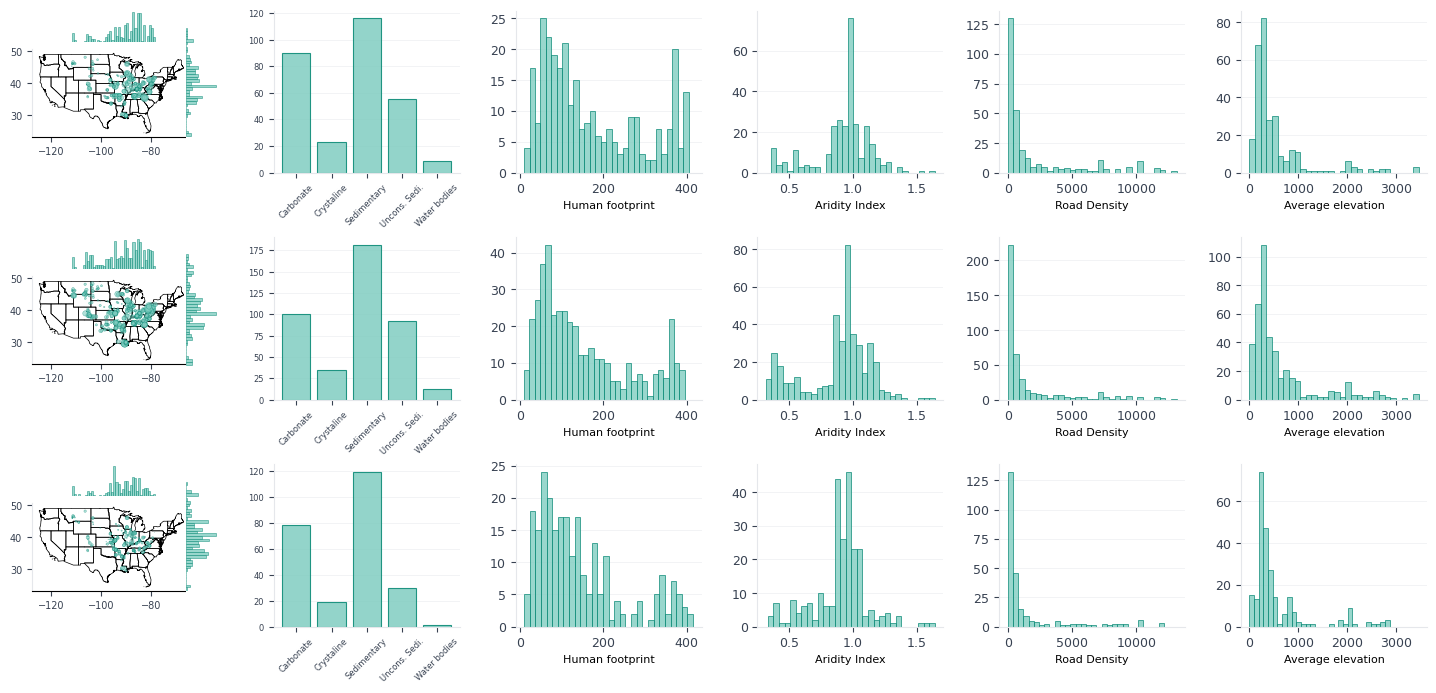

In [13]:
# Anxillary files
US_shp = gpd.read_file(USSF_filepath)
US_shp = US_shp.to_crs('EPSG:4326')

# Colour pallette
MAP_COLOR = '#2563EB'
HIST_COLOR = '#80cdc1'
HIST_EDGE = '#018571'
BG_COLOR = '#FFFFFF'
GRID_COLOR = '#E5E7EB'

params = {
    'DO_mgL': 'DO',
    'SpC_uScm': 'Cond.',
    'Turb_FNU': 'Turb.'
}

vars_cat = ['lit_cl_smj_remap']
vars_cont = ['hft_ix_s09', 'ari_ix_sav', 'rdd_mk_sav', 'ele_mt_sav']

# Shared x-axis limits for histograms
shared_xlims = {}
for var in vars_cont:
    global_min = md_gdf[var].min()
    global_max = md_gdf[var].max()
    margin = (global_max - global_min) * 0.05
    shared_xlims[var] = (global_min - margin, global_max + margin)
    
# Create gridspec: map with marginal histograms + bar + 4 histograms
fig = plt.figure(figsize=(18, 8))
gs = fig.add_gridspec(3, 6, hspace=0.4, wspace=0.3)

for j, (param_col, param_label) in enumerate(params.items()):
    md_gdf_filt = md_gdf[md_gdf['parameter'] == param_col]

    # --- Map with marginal distributions ---
    # Sub-gridspec for map cell (top-left)
    gs_map = gs[j, 0].subgridspec(2, 2, width_ratios=[5, 1], height_ratios=[1, 5], 
                                  hspace=-0.3, wspace=-0.05)
    
    ax_map = fig.add_subplot(gs_map[1, 0])
    ax_top = fig.add_subplot(gs_map[0, 0], sharex=ax_map)
    ax_right = fig.add_subplot(gs_map[1, 1], sharey=ax_map)

    # Main map
    US_shp.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=0.5)
    md_gdf_filt.plot(ax=ax_map,
                     color=HIST_COLOR, 
                     markersize=md_gdf_filt['longest_hr'] / 1000,
                     alpha=0.6, 
                     edgecolor=HIST_EDGE, 
                     linewidth=0.3)
    ax_map.tick_params(labelsize=7, colors='#374151')
    ax_map.spines[['top', 'right']].set_visible(False)
    ax_map.spines[['top', 'left']].set_color(GRID_COLOR)

    # Longitude distribution (top)
    lons = md_gdf_filt.geometry.x
    lats = md_gdf_filt.geometry.y
    ax_top.hist(lons, bins=40, color=HIST_COLOR, edgecolor=HIST_EDGE, linewidth=0.4, alpha=0.8)
    #ax_top.set_title(f'Stations with ≥1 meas. of {param_label}',
    #                 fontsize=10, fontweight='bold', pad=6)
    ax_top.tick_params(labelbottom=False, labelleft=False, left=False, bottom=False)
    ax_top.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    # Latitude distribution (right)
    ax_right.hist(lats, bins=40, orientation='horizontal',
                  color=HIST_COLOR, edgecolor=HIST_EDGE, linewidth=0.4, alpha=0.8)
    ax_right.tick_params(labelbottom=False, labelleft=False, left=False, bottom=False)
    ax_right.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    # --- Bar chart ---
    cntr = 1
    ax_bar = fig.add_subplot(gs[j, 1])
    for i, var in enumerate(vars_cat):
        cntr += 1
        counts = md_gdf_filt[var].value_counts().sort_index()
        ax_bar.bar(counts.index, counts.values,
                   color=HIST_COLOR, edgecolor=HIST_EDGE, linewidth=0.8, alpha=0.85)
        #ax_bar.set_title(param_dict[var], fontsize=11, fontweight='bold', pad=10)
        #ax_bar.set_xlabel(param_dict[var], fontsize=8)
        ax_bar.set_facecolor(BG_COLOR)
        ax_bar.spines[['top', 'right']].set_visible(False)
        ax_bar.spines[['left', 'bottom']].set_color(GRID_COLOR)
        ax_bar.tick_params(colors='#374151', labelsize=6)
        ax_bar.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
        ax_bar.set_axisbelow(True)
        ax_bar.tick_params(axis='x', rotation=45)

    # --- Histograms (remaining slots) ---
    hist_positions = [(j, 2), (j, 3), (j, 4), (j, 5)]
    for i, var in enumerate(vars_cont):
        row, col = hist_positions[i]
        a = fig.add_subplot(gs[row, col])
        a.hist(md_gdf_filt[var], bins=30,
               color=HIST_COLOR, edgecolor=HIST_EDGE, linewidth=0.6, alpha=0.8)
        a.set_xlim(shared_xlims[var])
        #a.set_title(param_dict[var], fontsize=11, fontweight='bold', pad=10)
        a.set_xlabel(param_dict[var], fontsize=8)
        a.set_facecolor(BG_COLOR)
        a.spines[['top', 'right']].set_visible(False)
        a.spines[['left', 'bottom']].set_color(GRID_COLOR)
        a.tick_params(colors='#374151', labelsize=9)
        a.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
        a.set_axisbelow(True)
    
    #plt.savefig(f'../OUTPUT/spatial_patterns/{param_col}_spatial_distributions.png', dpi=600, bbox_inches='tight')

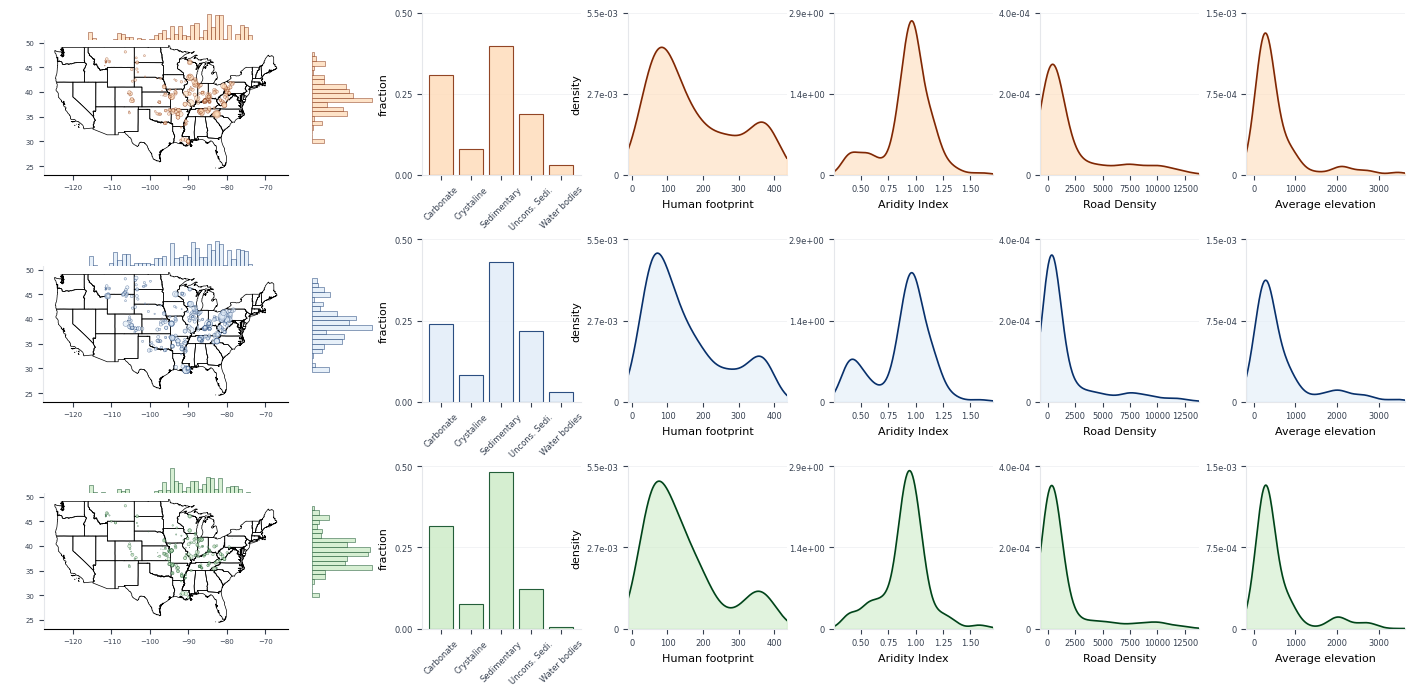

In [14]:
# Anxillary files
shared_ylims = {
    'lit_cl_smj_remap': 0.5,
    'hft_ix_s09': 0.0055,
    'ari_ix_sav': 2.9,
    'rdd_mk_sav': 0.0004,
    'ele_mt_sav': 0.0015
}

PARAM_COLORS = {
    'DO_mgL':    {'fill': '#FEDCBB', 'edge': '#7F2704'},
    'SpC_uScm':  {'fill': '#E2EDF8', 'edge': '#08306B'},
    'Turb_FNU':  {'fill': '#CEECC8', 'edge': '#00431A'},
}

params = {
    'DO_mgL': 'DO',
    'SpC_uScm': 'Cond.',
    'Turb_FNU': 'Turb.'
}

vars_cat = ['lit_cl_smj_remap']
vars_cont = ['hft_ix_s09', 'ari_ix_sav', 'rdd_mk_sav', 'ele_mt_sav']

# Shared x-axis limits for histograms
shared_xlims = {}
for var in vars_cont:
    global_min = md_gdf[var].min()
    global_max = md_gdf[var].max()
    margin = (global_max - global_min) * 0.05
    shared_xlims[var] = (global_min - margin, global_max + margin)
    
# Create gridspec: map with marginal histograms + bar + 4 histograms
fig = plt.figure(figsize=(18, 8))
gs = fig.add_gridspec(3, 7, hspace=0.4, wspace=0.3)

for j, (param_col, param_label) in enumerate(params.items()):

    fill_color = PARAM_COLORS[param_col]['fill']
    edge_color = PARAM_COLORS[param_col]['edge']
    md_gdf_filt = md_gdf[md_gdf['parameter'] == param_col]

    # --- Map with marginal distributions ---
    # Sub-gridspec for map cell (top-left)
    gs_map = gs[j, 0:2].subgridspec(2, 2, width_ratios=[5, 1], height_ratios=[1, 5],
                                 hspace=0, wspace=-0.05)
    
    ax_map = fig.add_subplot(gs_map[1, 0])
    ax_top = fig.add_subplot(gs_map[0, 0], sharex=ax_map)
    ax_right = fig.add_subplot(gs_map[1, 1], sharey=ax_map)

    # Main map
    US_shp.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=0.5)
    md_gdf_filt.plot(ax=ax_map,
                     color=fill_color, 
                     markersize=md_gdf_filt['longest_hr'] / 1000,
                     alpha=0.6, 
                     edgecolor=edge_color, 
                     linewidth=0.3)
    ax_map.tick_params(labelsize=5, colors='#374151')
    ax_map.spines[['top', 'right']].set_visible(False)
    ax_map.spines[['top', 'left']].set_color(GRID_COLOR)
    

    # Longitude distribution (top)
    lons = md_gdf_filt.geometry.x
    lats = md_gdf_filt.geometry.y
    ax_top.hist(lons, bins=40, color=fill_color, edgecolor=edge_color, linewidth=0.4, alpha=0.8)
    #ax_top.set_title(f'Stations with ≥1 meas. of {param_label}',
    #                 fontsize=10, fontweight='bold', pad=6)
    ax_top.tick_params(labelbottom=False, labelleft=False, left=False, bottom=False)
    ax_top.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    # Latitude distribution (right)
    ax_right.hist(lats, bins=20, orientation='horizontal',
                  color=fill_color, edgecolor=edge_color, linewidth=0.4, alpha=0.8)
    ax_right.tick_params(labelbottom=False, labelleft=False, left=False, bottom=False)
    ax_right.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    # --- Bar chart ---
    cntr = 1
    ax_bar = fig.add_subplot(gs[j, 2])
    for i, var in enumerate(vars_cat):
        cntr += 1
        counts = md_gdf_filt[var].value_counts().sort_index()
        ax_bar.bar(counts.index, counts.values/(counts.values.sum()),
                   color=fill_color, edgecolor=edge_color, linewidth=0.8, alpha=0.85)
        #ax_bar.set_title(param_dict[var], fontsize=11, fontweight='bold', pad=10)
        #ax_bar.set_xlabel(param_dict[var], fontsize=8)
        ax_bar.set_ylabel('fraction', fontsize=8)
        ax_bar.set_ylim(0, shared_ylims[var])
        ax_bar.set_yticks([0, shared_ylims[var]/2, shared_ylims[var]])
        
        ax_bar.set_facecolor(BG_COLOR)
        ax_bar.spines[['top', 'right']].set_visible(False)
        ax_bar.spines[['left', 'bottom']].set_color(GRID_COLOR)
        ax_bar.tick_params(colors='#374151', labelsize=6)
        ax_bar.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
        ax_bar.set_axisbelow(True)
        ax_bar.tick_params(axis='x', rotation=45)

    # --- Histograms (remaining slots) ---
    hist_positions = [(j, 3), (j, 4), (j, 5), (j, 6)]
    for i, var in enumerate(vars_cont):
        row, col = hist_positions[i]
        a = fig.add_subplot(gs[row, col])
        data = md_gdf_filt[var].dropna()
        kde = gaussian_kde(data)
        x_range = np.linspace(shared_xlims[var][0], shared_xlims[var][1], 300)
        a.fill_between(x_range, kde(x_range), color=fill_color, alpha=0.6)
        a.plot(x_range, kde(x_range), color=edge_color, linewidth=1.2)
        a.set_xlim(shared_xlims[var])
        a.set_xlabel(param_dict[var], fontsize=8)
        a.set_facecolor(BG_COLOR)
        a.spines[['top', 'right']].set_visible(False)
        a.spines[['left', 'bottom']].set_color(GRID_COLOR)
        a.tick_params(colors='#374151', labelsize=6)
        a.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
        a.set_axisbelow(True)
        if i == 0:
            a.set_ylabel('density', fontsize=8)

    # bar histograms
    #for i, var in enumerate(vars_cont):
    #    row, col = hist_positions[i]
    #    a = fig.add_subplot(gs[row, col])
    #    a.hist(md_gdf_filt[var], bins=30,
    #           color=HIST_COLOR, edgecolor=HIST_EDGE, linewidth=0.6, alpha=0.8)
    #    a.set_xlim(shared_xlims[var])
    #    #a.set_title(param_dict[var], fontsize=11, fontweight='bold', pad=10)
    #    a.set_xlabel(param_dict[var], fontsize=8)
    #    a.set_facecolor(BG_COLOR)
    #    a.spines[['top', 'right']].set_visible(False)
    #    a.spines[['left', 'bottom']].set_color(GRID_COLOR)
    #    a.tick_params(colors='#374151', labelsize=9)
    #    a.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
    #    a.set_axisbelow(True)
        
        a.set_ylim(0, shared_ylims[var])
        a.set_yticks([0, shared_ylims[var]/2, shared_ylims[var]])
        a.set_yticklabels(['0', f'{shared_ylims[var]/2:.1e}', f'{shared_ylims[var]:.1e}'], fontsize=6)
        
plt.savefig(f'../OUTPUT/spatial_patterns/parameter_spatial_distributions.png', dpi=600, bbox_inches='tight')

# Path length analysis

In [15]:
# !! There is one STREAM station without a comid. 
comid_pl = pd.read_csv(ancillary_data_filepath+"geomorph_data/nhdplus_pathlength.csv")
comid_pl.head(2)

,STREAM_ID,reachcode,comid,pathlength
0,STREAM-gauge-1723,5.010001e+12,8972788,3603
1,STREAM-gauge-2691,5.010001e+12,8969860,3506


In [16]:
# Attaching comid and path length to metadata
md_data = md_data.merge(comid_pl)
md_data.head()

,STREAM_ID,sourceID,source,site name,latitude_wgs84,longitude_wgs84,drainagearea_sqkm,state_name,time_zone,parameter,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav,clz_cl_smj_remap,lit_cl_smj_remap,pct_missing,length_hr,longest_hr,reachcode,comid,pathlength
0,STREAM-gauge-699,6805500,USGS,"Platte River at Louisville, Nebr",41.014978,-96.157500,221107.44630,Nebraska,Central,SpC_uScm,10.0,0.730000,0.000000,16.862000,307.000000,177.000000,1.800000,3.0,354.000000,6,Sedimentary,47.56,156537.0,2354.0,1.020020e+13,17416036,2846
1,STREAM-gauge-2815,7137500,USGS,"ARKANSAS R NR COOLIDGE, KS",38.027517,-102.011577,65811.64590,Kansas,Mountain,SpC_uScm,9.0,0.344924,23.849569,9.463323,152.865259,48.414293,4.012263,3.0,1831.753307,6,Sedimentary,9.53,156548.0,7212.0,1.103000e+13,21247638,2675
2,STREAM-gauge-2793,6856600,USGS,"REPUBLICAN R AT CLAY CENTER, KS",39.355552,-97.127520,63563.53458,Kansas,Central,SpC_uScm,9.0,0.434286,8.239190,2.097020,94.229848,60.629178,1.180475,3.0,957.662762,6,Sedimentary,10.52,61646.0,4370.0,1.025000e+13,5926514,2795
3,STREAM-gauge-1769,3108500,USGS,"Ohio River at Montgomery Lock & Dam, Lower Pool",40.647241,-80.388666,59466.17040,Pennsylvania,Eastern,SpC_uScm,10.0,1.113137,30.842322,74.117446,797.900344,153.888438,5.843242,3.0,488.909913,6,Sedimentary,0.96,24173.0,5001.0,5.030101e+12,3821065,3077
4,STREAM-gauge-3006,6174500,USGS,Milk River at Nashua MT,48.130053,-106.364314,58150.45548,Montana,Mountain,SpC_uScm,8.0,0.366990,1.075479,0.739630,54.655445,30.733556,1.922866,3.0,924.904450,5,Sedimentary,30.36,11344.0,3136.0,1.005000e+13,12308335,4724


DO_mgL: min=1.0000, max=22.0000
SpC_uScm: min=1.0000, max=28.0000
Turb_FNU: min=1.0000, max=18.0000


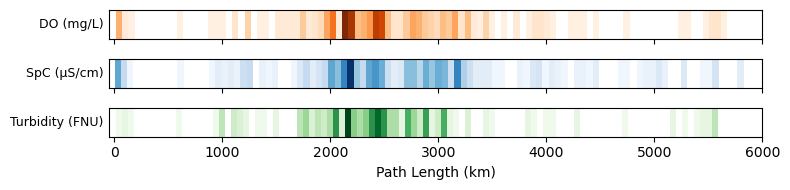

In [17]:
# network density map
fig, axes = plt.subplots(3, 1, figsize=(8, 2), sharex=True)
cmap_names = ['Oranges', 'Blues', 'Greens'] 

params = ['DO_mgL', 'SpC_uScm', 'Turb_FNU']
labels = ['DO (mg/L)', 'SpC (μS/cm)', 'Turbidity (FNU)']

for ax, param, label, cmap_name in zip(axes, params, labels, cmap_names):
    subset = md_data[md_data['parameter'] == param]['pathlength'].dropna()
    counts, bin_edges = np.histogram(subset, bins=100, density=True)
    
    cmap = plt.get_cmap(cmap_name)  # ← get the actual colormap object

    # Map colors: white where no data, colormap where data exists
    colors = np.array([cmap(c / counts.max()) if c > 0 else (1, 1, 1, 1) for c in counts])
    
    ax.bar(bin_edges[:-1], np.ones_like(counts), width=np.diff(bin_edges),
           color=colors,
           align='edge')
    
    ax.set_ylabel(label, fontsize=9, 
                  rotation=0, 
                  ha='right', 
                      verticalalignment='center')
    
    ax.set_yticks([])
    ax.set_xlim([-50, 6000])

axes[-1].set_xlabel("Path Length (km)")

plt.tight_layout()
plt.savefig(f'../OUTPUT/spatial_patterns/denstiy_network_length.png', dpi=600, bbox_inches='tight')

for param, cmap_name in zip(params, cmap_names):
    subset = md_data[md_data['parameter'] == param]['pathlength'].dropna()
    counts, bin_edges = np.histogram(subset, bins=100, density=False)
    print(f"{param}: min={counts[counts>0].min():.4f}, max={counts.max():.4f}")

In [18]:
shapefile_filepath = '../INPUT/03_shapefiles/'

In [19]:
# Heatmap of watersheds to better represent spatial distribution
cnt = 0
missing_sites = []
heatmaps = {} # dict for heatmap rasters
# Defining grod
raster_res = 0.01
bounds = US_shp.total_bounds # using US state shapfile for bounds
width = int((bounds[2] - bounds[0]) / raster_res)
height = int((bounds[3] - bounds[1]) / raster_res)
transform = from_bounds(*bounds, width, height)

for param in params:
    # Empty heatmap for each parameter
    heatmap = np.zeros((height, width), dtype='float32')
    md_data_i = md_data[md_data['parameter'] == param]
    for j, row in md_data_i.iterrows():
        site_id = row['STREAM_ID']
        try:
            wtshd = gpd.read_file(shapefile_filepath+site_id+'.shp')
            geom = wtshd.geometry.iloc[0]
            r = rasterize([(geom, 1)], out_shape=(height, width), transform=transform, fill=0, dtype='uint8')
            heatmap += r
            # heatmap_hours += r * hours # if you want to scale it by hours of data available.
        except:
            cnt = cnt + 1
            missing_sites.append(site_id)
    heatmaps[param] = heatmap
    
    print(f'Error for {cnt} watersheds.')

Error for 22 watersheds.
Error for 45 watersheds.
Error for 47 watersheds.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, param in zip(axes, params):
    heatmap_masked = np.ma.masked_where(heatmaps[param] == 0, heatmaps[param])
    cmap = plt.cm.YlOrRd
    cmap.set_bad(color='none')
    im = ax.imshow(heatmap_masked, extent=[bounds[0], bounds[2], bounds[1], bounds[3]], cmap=cmap)
    US_shp.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)
    ax.set_title(param)

#fig.colorbar(im, ax=axes, label='Watershed overlap count', shrink=0.6)
plt.tight_layout()
plt.show()